In [8]:
%load_ext autoreload
%autoreload 2

from tasks.math_ops.triple_add_12_3 import triple_add_task, sample_triple_add_problem

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Load LM
from neural.pipeline import LMPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "allenai/OLMo-2-0425-1B"
# model_name = "Qwen/Qwen2.5-0.5B"
pipeline = LMPipeline(model_name, max_new_tokens=1, device=device, dtype=torch.float32, max_length=32)
pipeline.tokenizer.padding_side = "left"

def checker(neural_output, causal_output):
    return causal_output in neural_output["string"] or neural_output["string"] in causal_output

print("DEVICE:", pipeline.model.device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

DEVICE: cuda:0


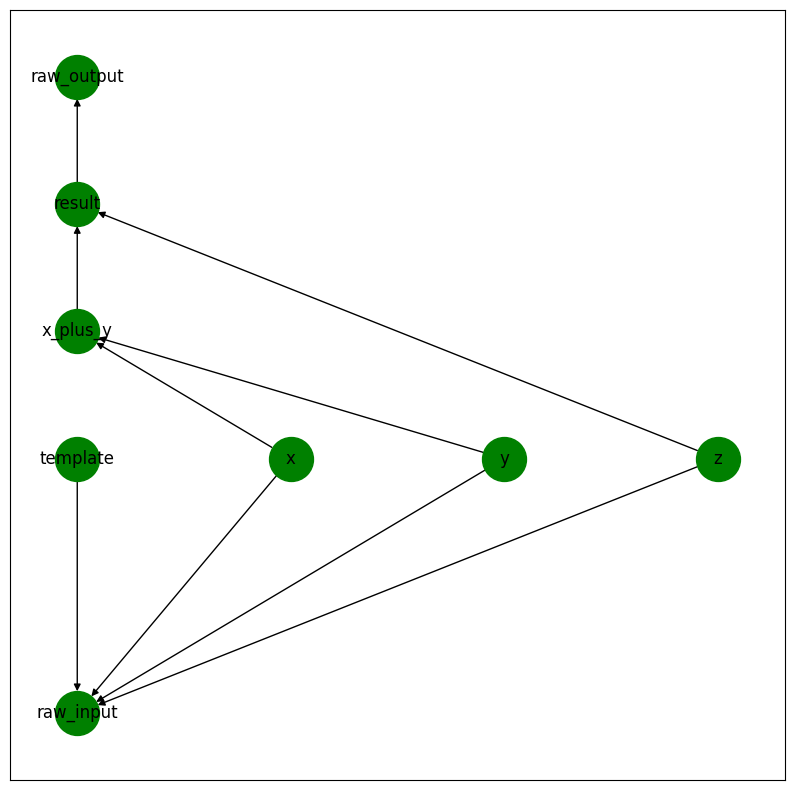

In [10]:
# Define a causal model
causal_model_triple = triple_add_task.causal_models["three_number_addition"]

causal_model_triple.print_structure()

In [11]:
# Generate an example
example = sample_triple_add_problem()
example

{'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
 'x': 10,
 'y': 3,
 'z': 14,
 'raw_input': '<|endoftext|>, Yes, 10 + 3 + 14 = '}

In [12]:
# Run the causal model forward
full_setting = causal_model_triple.run_forward(example)
full_setting

defaultdict(None,
            {'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
             'x': 10,
             'y': 3,
             'z': 14,
             'x_plus_y': 13,
             'result': 27,
             'raw_input': '<|endoftext|>, Yes, 10 + 3 + 14 = ',
             'raw_output': '27'})

In [13]:
# Manually intervene on x_plus_y and rerun
example["x_plus_y"] = 0
causal_model_triple.run_forward(example)

defaultdict(None,
            {'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
             'x': 10,
             'y': 3,
             'z': 14,
             'x_plus_y': 0,
             'result': 14,
             'raw_input': '<|endoftext|>, Yes, 10 + 3 + 14 = ',
             'raw_output': '14'})

In [14]:
# Confirm interchange intervention works as expected
example = sample_triple_add_problem()
full_setting = causal_model_triple.run_forward(example)
new_example = sample_triple_add_problem()
new_full_setting = causal_model_triple.run_forward(new_example)

x0, y0, z0 = example["x"], example["y"], example["z"]
print(f"Original is {x0} + {y0} + {z0}  =  {x0+y0} + {z0}  =  {x0+y0+z0}")

x1, y1, z1 = new_example["x"], new_example["y"], new_example["z"]
print(f"New one  is {x1} + {y1} + {z1}  =  {x1+y1} + {z1}  =  {x1+y1+z1}")
print()
print(f"Intervention should be {x1+y1} + {z0}  =  {x1+y1+z0}")

intervened_full_setting = causal_model_triple.run_interchange(example, {"x_plus_y": new_example})
intervened_full_setting

Original is 14 + 5 + 5  =  19 + 5  =  24
New one  is 7 + 15 + 10  =  22 + 10  =  32

Intervention should be 22 + 5  =  27


defaultdict(None,
            {'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ',
             'x': 14,
             'y': 5,
             'z': 5,
             'x_plus_y': 22,
             'result': 27,
             'raw_input': '<|endoftext|>, Yes, 14 + 5 + 5 = ',
             'raw_output': '27'})

Original:
Causal output is 7 + 10 + 7  =  17 + 7  =  24
Neural output is 24

Counterfactual:
Causal output is 11 + 9 + 13  =  20 + 13  =  33
Neural output is 33

Intervention should be 20 + 7  =  27

Running SameLengthResidualStreamTracing experiment...


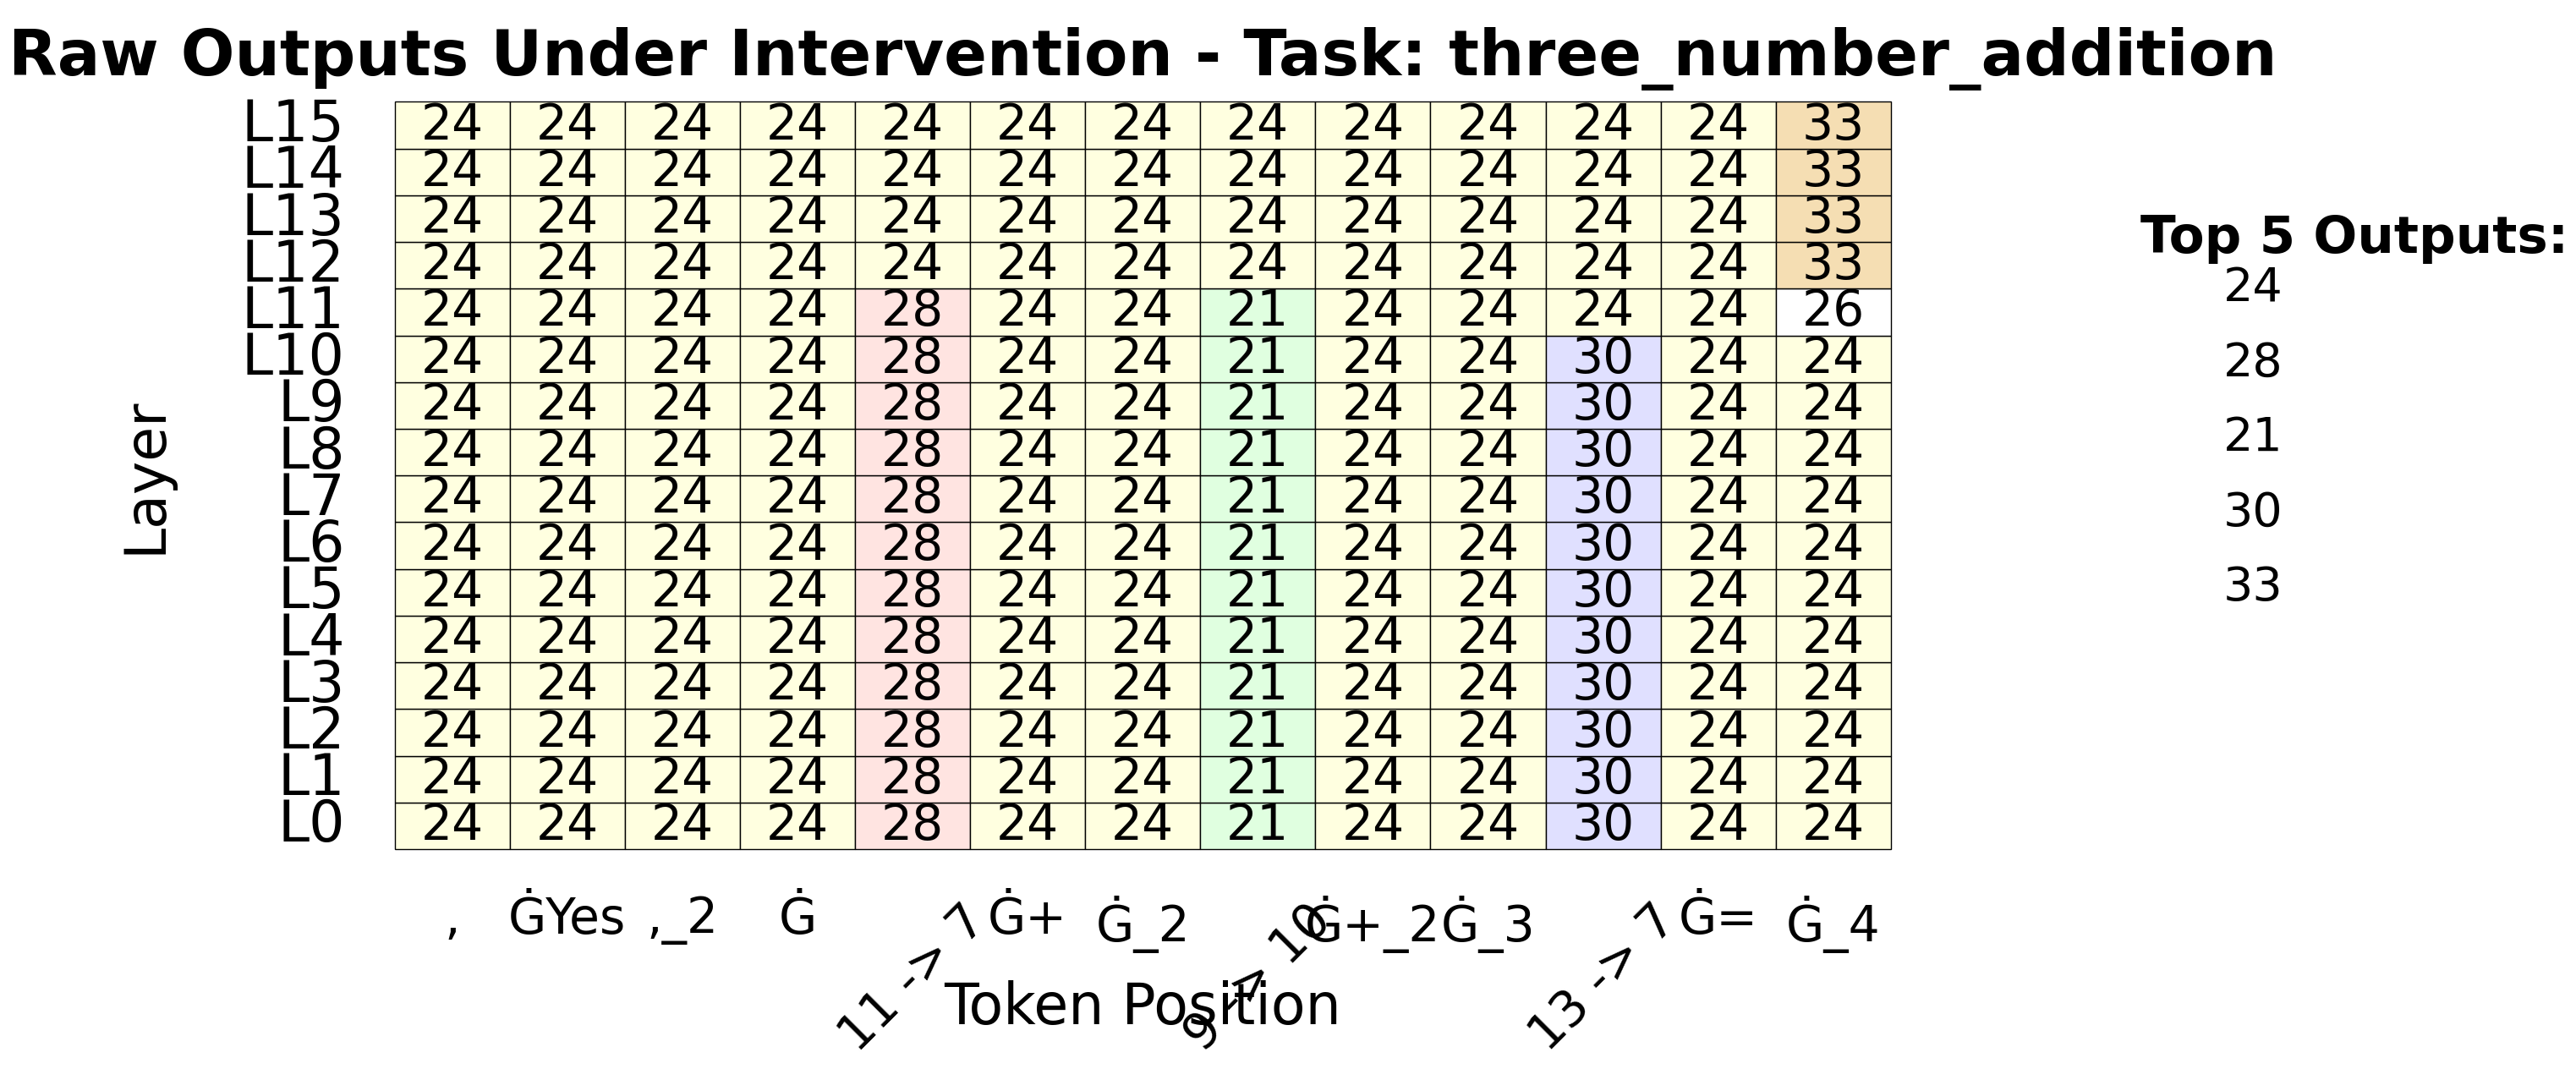


Tracing completed for 4 layer-position combinations


In [15]:
# Compare LM outputs for single pair intervention
# Takes about 35 seconds

# Import the tracing experiment
from experiments.LM_experiments.residual_stream_experiment import SameLengthResidualStreamTracing

original = sample_triple_add_problem()
counterfactual = sample_triple_add_problem()

x0, y0, z0 = original["x"], original["y"], original["z"]
neural_output = pipeline.generate(original["raw_input"])["string"]
print("Original:")
print(f"Causal output is {x0} + {y0} + {z0}  =  {x0+y0} + {z0}  =  {x0+y0+z0}")
print(f"Neural output is {neural_output}")

x1, y1, z1 = counterfactual["x"], counterfactual["y"], counterfactual["z"]
neural_output = pipeline.generate(counterfactual["raw_input"])["string"]
print("\nCounterfactual:")
print(f"Causal output is {x1} + {y1} + {z1}  =  {x1+y1} + {z1}  =  {x1+y1+z1}")
print(f"Neural output is {neural_output}")
print()
print(f"Intervention should be {x1+y1} + {z0}  =  {x1+y1+z0}")

# Run the tracing experiment
print("\n" + "="*50)
print("Running SameLengthResidualStreamTracing experiment...")
print("="*50)

# Create the tracing experiment
tracing_exp = SameLengthResidualStreamTracing(
    pipeline=pipeline,
    causal_model=causal_model_triple,
    checker=checker,
)

# Run the experiment with our counterfactual pair
results = tracing_exp.run(
    base_input=original,
    counterfactual_input=counterfactual
)

tracing_exp.plot_raw_outputs(results, "./tracing_results/tracing_heatmap.png")
print(f"\nTracing completed for {len(results)} layer-position combinations")

In [16]:
# Generates 64 random pairs (both are random, not just the counterfactual)
from causal.counterfactual_dataset import CounterfactualDataset

size = 64

random_pairs = CounterfactualDataset.from_sampler(size, triple_add_task.dataset_generators["distinct_counterfactual"])

print(random_pairs[0])
print()
print("Original input:")
print(random_pairs[0]["input"]["raw_input"])
print("\nCounterfactual input:")
print(random_pairs[0]["counterfactual_inputs"][0]["raw_input"])
print("\nOriginal input:")
print(random_pairs[1]["input"]["raw_input"])
print("\nCounterfactual input:")
print(random_pairs[1]["counterfactual_inputs"][0]["raw_input"])

{'input': {'raw_input': '<|endoftext|>, Yes, 6 + 18 + 11 = ', 'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ', 'x': 6, 'y': 18, 'z': 11}, 'counterfactual_inputs': [{'raw_input': '<|endoftext|>, Yes, 15 + 3 + 7 = ', 'template': '<|endoftext|>, Yes, <x> + <y> + <z> = ', 'x': 15, 'y': 3, 'z': 7}]}

Original input:
<|endoftext|>, Yes, 6 + 18 + 11 = 

Counterfactual input:
<|endoftext|>, Yes, 15 + 3 + 7 = 

Original input:
<|endoftext|>, Yes, 6 + 13 + 17 = 

Counterfactual input:
<|endoftext|>, Yes, 16 + 16 + 1 = 


In [17]:
# Check distinguishability of pairs of variables
causal_model_triple.can_distinguish_with_dataset(random_pairs, ["result"], None)
causal_model_triple.can_distinguish_with_dataset(random_pairs, ["x_plus_y"], None)
causal_model_triple.can_distinguish_with_dataset(random_pairs, ["result"], ["x_plus_y"])
pass

Can distinguish between ['result'] and None: 64 out of 64 examples
Proportion of distinguishable examples: 1.00
Can distinguish between ['x_plus_y'] and None: 64 out of 64 examples
Proportion of distinguishable examples: 1.00
Can distinguish between ['result'] and ['x_plus_y']: 64 out of 64 examples
Proportion of distinguishable examples: 1.00


In [18]:
# Compute interchange intervention accuracy
# Ie create heatmaps
from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

token_positions = list(triple_add_task.create_token_positions(pipeline).values())

start = 0
end = pipeline.get_num_layers()
config = {"batch_size":64}
target_variables_list  = [[], ["x"], ["y"], ["z"], ["x_plus_y"], ["result"]]
results_dir = "vector_patching_results"

experiment = PatchResidualStream(pipeline, causal_model_triple, list(range(start, end)), token_positions, checker, config=config)
raw_results = experiment.perform_interventions({'random_pairs': random_pairs}, verbose=True, target_variables_list=target_variables_list)
# Takes like 44 sec
# With plus_one positions included, takes like 68 sec

Running interventions:   0%|          | 0/144 [00:00<?, ?it/s, dataset=random_pairs, units=[[AtomicModelUnit(id='ResidualStream(Layer-0,Token-x)')]]]

Running interventions: 100%|██████████| 144/144 [01:25<00:00,  1.68it/s, dataset=random_pairs, units=[[AtomicModelUnit(id='ResidualStream(Layer-15,Token-last_token)')]]]


vector_patching_results/heatmap_dataset_random_pairs_task_three_number_addition_variables_.png


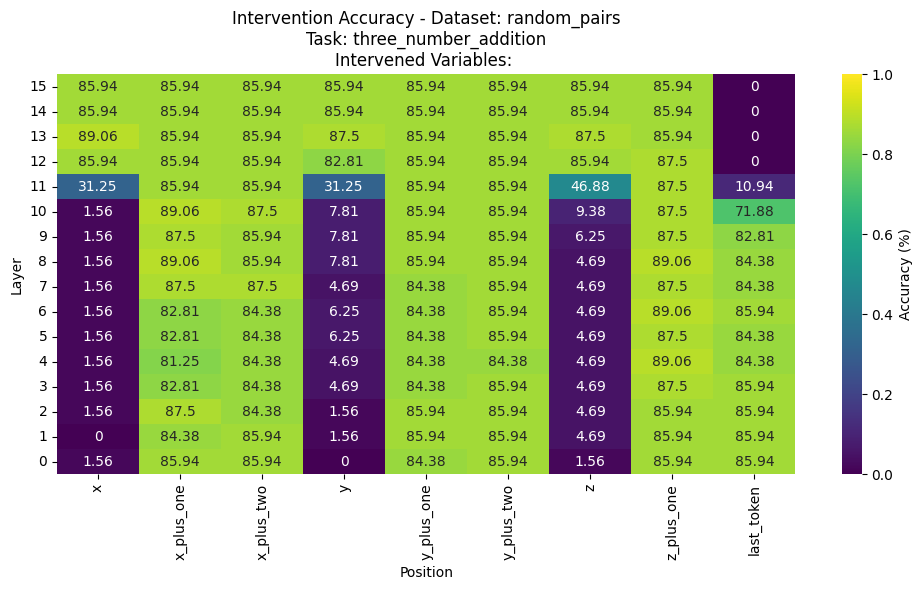

vector_patching_results/heatmap_dataset_random_pairs_task_three_number_addition_variables_x.png


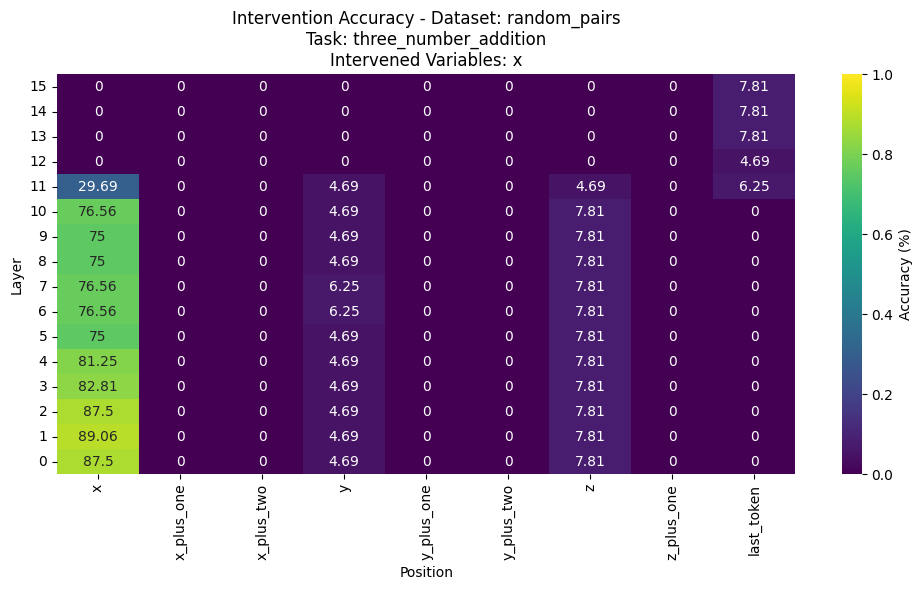

vector_patching_results/heatmap_dataset_random_pairs_task_three_number_addition_variables_y.png


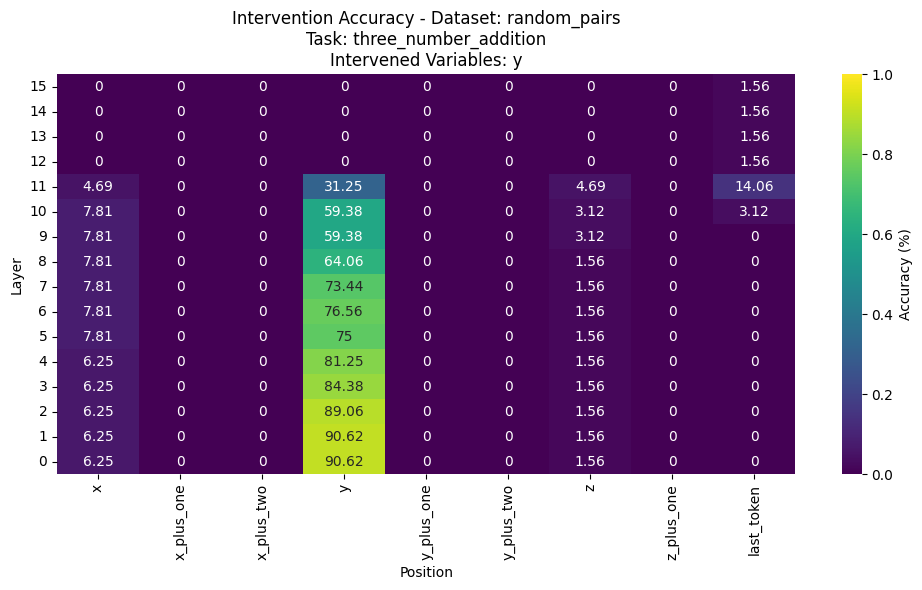

vector_patching_results/heatmap_dataset_random_pairs_task_three_number_addition_variables_z.png


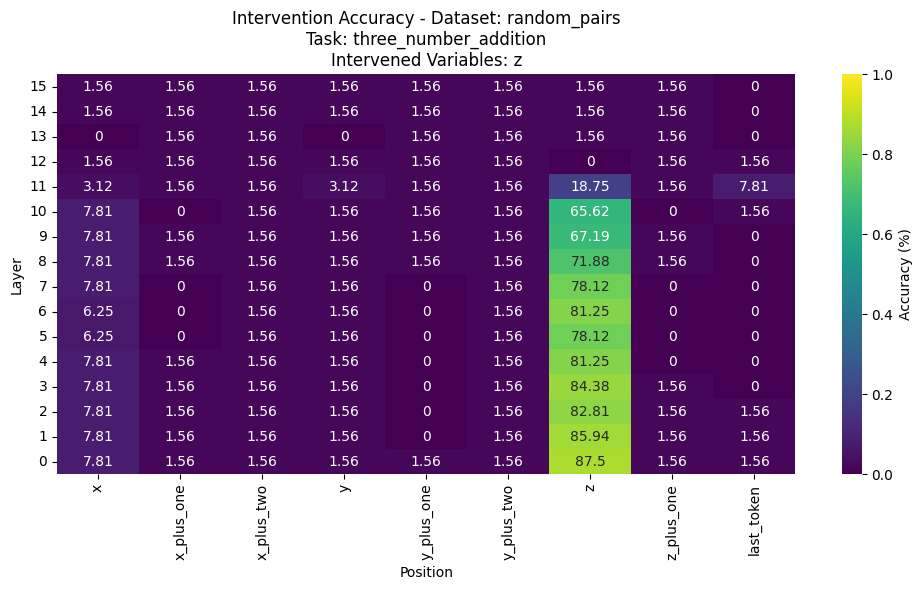

vector_patching_results/heatmap_dataset_random_pairs_task_three_number_addition_variables_x_plus_y.png


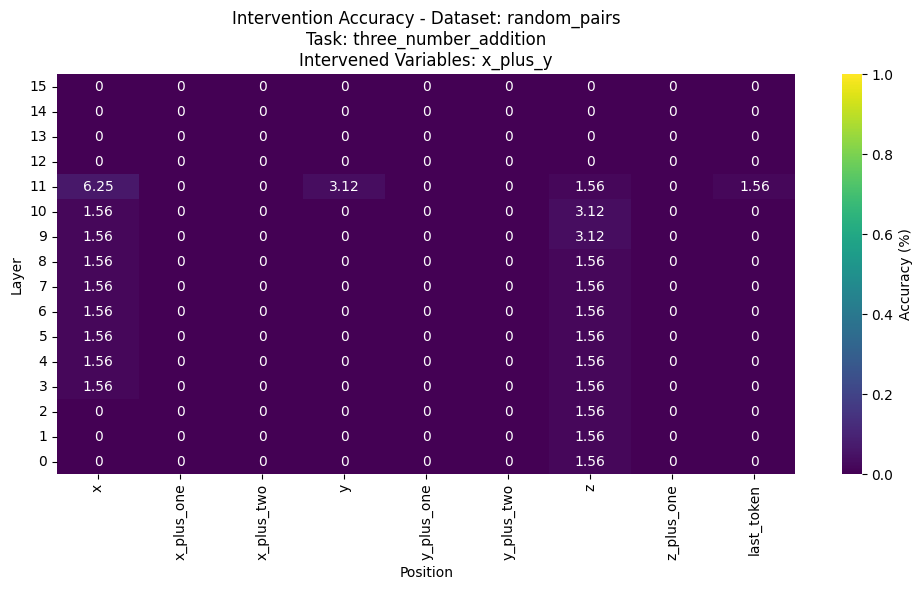

vector_patching_results/heatmap_dataset_random_pairs_task_three_number_addition_variables_result.png


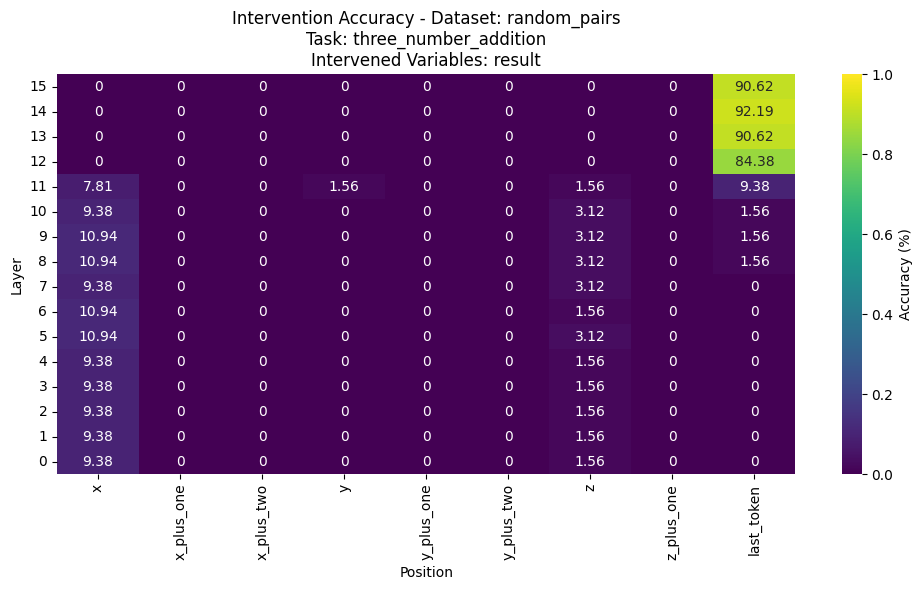

In [19]:
# Show heatmaps
experiment.plot_heatmaps(raw_results, [], save_path=results_dir)
experiment.plot_heatmaps(raw_results, ["x"], save_path=results_dir)
experiment.plot_heatmaps(raw_results, ["y"], save_path=results_dir)
experiment.plot_heatmaps(raw_results, ["z"], save_path=results_dir)
experiment.plot_heatmaps(raw_results, ["x_plus_y"], save_path=results_dir)
experiment.plot_heatmaps(raw_results, ["result"], save_path=results_dir)

In [20]:
# Check dim of residual stream

# from transformers import AutoTokenizer, AutoModel
# import torch

# model = AutoModel.from_pretrained(model_name)
# tokenizer = AutoTokenizer.from_pretrained(model_name)

# text = "The fox jumps over lazy dog."
# inputs = tokenizer(text, return_tensors="pt")

# with torch.no_grad():
#     outputs = model(**inputs, output_hidden_states=True)
#     # The last element in outputs.hidden_states is (batch, seq_len, hidden_size)

# x = outputs.hidden_states
# print(f"Number of layers (+1) is {len(x)}")
# print(f"Shape (B,T,C) is {x[3].shape}")


In [21]:
# # Do DAS (obsolete)
# from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

# # Was 64, 128, 4, 16
# config = {
#     "batch_size": 8, 
#     "evaluation_batch_size": 8, 
#     "training_epoch": 10,
#     "DAS": {"n_features": 128}
# }
# start = 0
# end = pipeline.get_num_layers()
# target_variables_list  = [["x"]] # [["x"], ["y"], ["z"], ["x_plus_y"], ["result"]]
# results_dir = "DAS_results"

# token_positions = triple_add_task.create_token_positions(pipeline)

# dataset = {'random_pairs': random_pairs}

# experiment = PatchResidualStream(pipeline, causal_model_triple, list(range(start, end)), list(token_positions.values()), checker, config=config)
# experiment.train_interventions(dataset, ["result"], method="DAS", verbose=False)
# raw_results = experiment.perform_interventions(dataset, verbose=False, target_variables_list=target_variables_list, save_dir=results_dir)

# # Took 2 min 55 sec for target [["x"], ["y"], ["z"], ["x_plus_y"], ["result"]]
# # Took 2 min 52 sec for target [["x"]]
# # Changed to single layer, batch size 1, 16 epochs
# # Took 38 sec target [["x"]]
#     # Only got to 3%
# # Changed from 16 to 128 features
#     # Took 37.4 sec, got 3%
# # Changed from 128 to 1024 features
#     # Took 38.5 sec, got 6%
# # Changed from 1024 to 2048 features
#     # Took 38 sec, got 6%
# # Changed to 1 epoch, still with 2048 features
#     # Took 6 sec and got 25% then 37.5%
# # With 8, 8, 5, 1024:
#     # After 1 epoch was 18% and after 5 was 9%

# # n_features stuff
# # No subdict, n_features = 0, I get 12.5, 14, 16, 17%
# # No subdict, n_features = 2048, I get 5, 6, 19, 13%
# # Yes subdict, n_features = 0, I get 0, 0%
# # Yes subdict, n_features = 1024, I get 60.94, 65.62,71.88%
# # Yes subdict, n_features = 2048, I get 89.06, 89.06%%
#     # I think it works but it's just that the LLM only gets 57/64 correct

In [22]:
# # Do DAS (confirm last layer can be trained)
# # 16 features is sufficient, it seems
# from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

# config = {
#     "batch_size": 8, 
#     "evaluation_batch_size": 8, 
#     "training_epoch": 1,
#     "DAS": {"n_features": 64}
# }
# start = 15
# end = pipeline.get_num_layers()
# target_variables_list  = [["result"]] # [["x"], ["y"], ["z"], ["x_plus_y"], ["result"]]
# results_dir = "DAS_results"

# token_positions = triple_add_task.create_token_positions(pipeline)

# dataset = {'random_pairs': random_pairs}

# experiment = PatchResidualStream(pipeline, causal_model_triple, list(range(start, end)), list(token_positions.values()), checker, config=config)
# experiment.train_interventions(dataset, ["result"], method="DAS", verbose=False)
# raw_results = experiment.perform_interventions(dataset, verbose=False, target_variables_list=target_variables_list, save_dir=results_dir)

# # print("TRAINING DATASETS RESULTS")
# # experiment.plot_heatmaps(raw_results, ["result"], save_path=results_dir)

# # 2048 features
#     # 1 epoch (w/ 8,8) gets 84%
# # 1024 features
#     # 1 epoch (w/ 8,8) gets 70, 72, 75%
# # 512 features
#     # 1 epoch (w/ 8,8) gets 69, 73, 75
# # 256 features
#     # 1 epoch (w/ 8,8) gets 64, 66, 70
# # 128 features
#     # 1 epoch (w/ 8,8) gets 58, 63, 70
# # 64 features
#     # 1 epoch (w/ 8,8) gets 58, 59, 66
#     # 2 epochs (w/ 8,8) gets 89, 91, 95
# # 32 features
#     # 1 epoch (w/ 8,8) gets 66, 70, 72
#     # 2 epochs (w/ 8,8) gets 86, 92, 92
# # 16 features
#     # 1 epoch (w/ 8,8) gets 58, 70, 70
#     # 2 epochs (w/ 8,8) gets 86, 92, 92
#     # 10 epochs (w/ 8,8) gets 100, 100, 100
# # 8 features
#     # 1 epoch (w/ 8,8) gets 36, 47, 52
#     # 5 epochs (w/ 8,8) gets 81, 92, 91
#     # 10 epochs (w/ 8,8) gets 98, 98, 98
# # 4 features
#     # 1 epoch (w/ 8,8) gets 17, 22, 25
# # 2 features
#     # 1 epoch (w/ 8,8) gets 2, 6, 11
#     # 5 epochs (w/ 8,8) gets 16, 19, 19
# # 1 feature
#     # 1 epoch (w/ 8,8) gets 2, 5, 5
# # 0 features
#     # 1 epoch (w/ 8,8) gets 0, 0, 0

In [23]:
# # Do DAS (confirm first layer can be trained)
# # 16 is still sufficient!
# from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

# config = {
#     "batch_size": 32, 
#     "evaluation_batch_size": 64, 
#     "training_epoch": 1,
#     "DAS": {"n_features": 16},
#     # "init_lr": 1e-2
# }
# start = 0
# end = 1 # pipeline.get_num_layers()
# train_variables = ["x"]
# target_variables_list  = [["x"]] # [["x"], ["y"], ["z"], ["x_plus_y"], ["result"]]
# results_dir = "DAS_results"

# token_positions = triple_add_task.create_token_positions(pipeline)

# train_size = 64
# test_size = 64
# random_pairs = CounterfactualDataset.from_sampler(train_size, triple_add_task.dataset_generators["distinct_counterfactual"])
# train_set = {'train_pairs': random_pairs}
# random_pairs = CounterfactualDataset.from_sampler(test_size, triple_add_task.dataset_generators["distinct_counterfactual"])
# test_set = {'test_pairs': random_pairs}

# experiment = PatchResidualStream(pipeline, causal_model_triple, list(range(start, end)), list(token_positions.values()), checker, config=config)
# experiment.train_interventions(train_set, train_variables, method="DAS", verbose=False)
# train_results = experiment.perform_interventions(train_set, verbose=False, target_variables_list=target_variables_list, save_dir=results_dir)
# test_results = experiment.perform_interventions(test_set, verbose=False, target_variables_list=target_variables_list, save_dir=results_dir)

# # print("TRAINING DATASETS RESULTS")
# # experiment.plot_heatmaps(train_results, train_variables, save_path=results_dir)
# # experiment.plot_heatmaps(test_results, train_variables, save_path=results_dir)

# # Used batch 64, train 64, test 64, no lr
# # 2048
#     # 1 epoch gets 86 train, 81 test
# # 1024
#     # 1 epoch gets  73 train, 67 test
#     # 2 epochs gets 80 train, 73 test
#     # 3 epochs gets 86 train, 66 test
#     # 4 epochs gets 91 train, 66 test
#     # 5 epochs gets 94 train, 77 test
# # 512
#     # 1 epoch gets 67 train, 64 test
# # 256
#     # 1 epoch gets  70 train, 66 test
#     # 2 epochs gets 86 train, 56 test
#     # 3 epochs gets 83 train, 73 test
#     # 4 epochs gets 94 train, 75 test
# # 128
#     # 1 epoch gets 50 train, 45 test
# # 64
#     # 1 epoch gets 47 train, 47 test
# # 1
#     # 1 epoch gets 3  train, 2  test

# # Use batch 32, train 1024, test 64, no lr
# # 256
#     # 1 epoch gets 86 train, 78 test
#     # Tried again, 86 train, 89 test (took 73 sec)
# # 16
#     # 1 epoch gets  86 train, 77 test
#     # 2 epochs gets 91 train, 83 test

In [ ]:
# Do DAS
from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

config = {
    "batch_size": 32, 
    "evaluation_batch_size": 64, 
    "training_epoch": 1,
    "DAS": {"n_features": 32},
    # "init_lr": 1e-2
}
start = 0
end = pipeline.get_num_layers()
train_variables = ["x_plus_y"]
target_variables_list  = [["x_plus_y"]] # [["x"], ["y"], ["z"], ["x_plus_y"], ["result"]]
results_dir = "DAS_results"

token_positions = triple_add_task.create_token_positions(pipeline)

train_size = 2048
test_size = 64
random_pairs = CounterfactualDataset.from_sampler(train_size, triple_add_task.dataset_generators["distinct_counterfactual"])
train_set = {'train_pairs': random_pairs}
random_pairs = CounterfactualDataset.from_sampler(test_size, triple_add_task.dataset_generators["distinct_counterfactual"])
test_set = {'test_pairs': random_pairs}

experiment = PatchResidualStream(pipeline, causal_model_triple, list(range(start, end)), list(token_positions.values()), checker, config=config)
experiment.train_interventions(train_set, train_variables, method="DAS", verbose=False)
train_results = experiment.perform_interventions(train_set, verbose=False, target_variables_list=target_variables_list, save_dir=results_dir)
test_results = experiment.perform_interventions(test_set, verbose=False, target_variables_list=target_variables_list, save_dir=results_dir)

print("TRAINING DATASETS RESULTS")
experiment.plot_heatmaps(train_results, train_variables, save_path=results_dir)
experiment.plot_heatmaps(test_results, train_variables, save_path=results_dir)

# With single training point, 1 epoch
    # Took 65 sec
# With 16 features, batch 32, train 512, 1 epoch, full layers, didn't really get any signal.
    # Last token layer 12 got 11.3%, most were below 4%
    # Some layers of y also got near 10%, with layer 7 getting 10.2%
    # Took 8 min
# With 32 features, batch 32, train 2048, 1 epoch, full layers
    # For train, last token layers 11, 12, 13 got around 11% and y seemed a bit enriched in layers 2-11, being like 7-9% rather than 4%
    # For test, y was even more enriched with layer 8 getting 11%. Doesn't seem to have much signal in last token though.

Training [[AtomicModelUnit(id='ResidualStream(Layer-1,Token-z)')]]...:   0%|          | 0/1 [00:00<?, ?it/s]                                                                      